In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [4]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df = df.drop_duplicates()
df.shape

(5169, 2)

In [10]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [11]:
(df['label'].value_counts(normalize=True) * 100).round(2)

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64

In [12]:
df['char_count'] = df['message'].apply(len)

In [13]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

In [14]:
df['sentence_count'] = df['message'].apply(
    lambda x: len([s for s in x.split('.') if s.strip()]))

In [15]:
df.head()

,label,message,char_count,word_count,sentence_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,3
1,ham,Ok lar... Joking wif u oni...,29,6,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,ham,U dun say so early hor... U c already then say...,49,11,2
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [16]:
df.groupby('label')[['char_count', 'word_count', 'sentence_count']].mean()

,char_count,word_count,sentence_count
label,,,
ham,70.459256,14.134632,1.872896
spam,137.891271,23.681470,2.882083


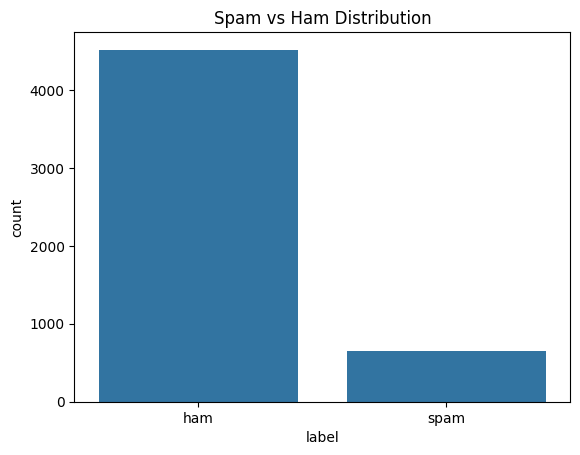

In [17]:
sns.countplot(data=df, x='label')
plt.title("Spam vs Ham Distribution")
plt.show()

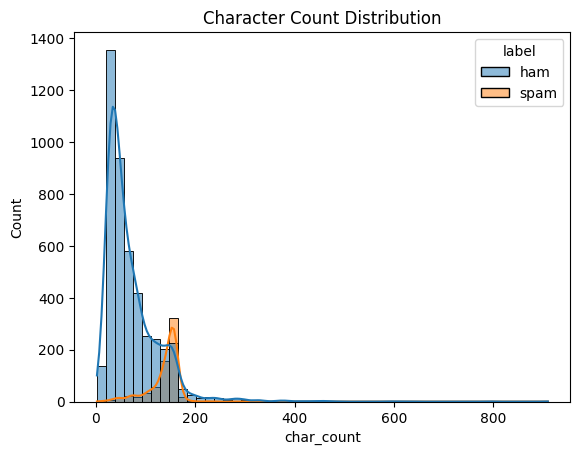

In [18]:
sns.histplot(data=df, x='char_count', hue='label', bins=50, kde=True)
plt.title("Character Count Distribution")
plt.show()

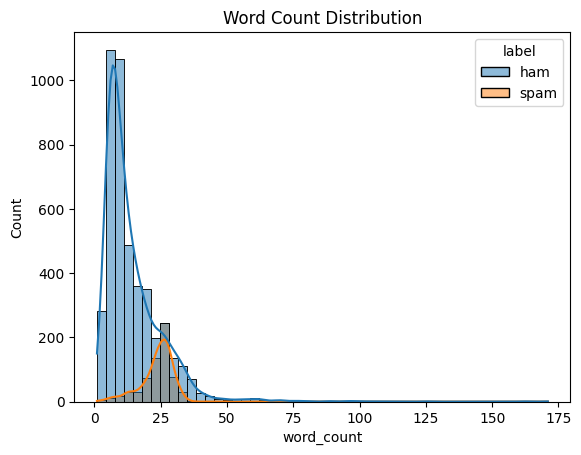

In [19]:
sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True)
plt.title("Word Count Distribution")
plt.show()

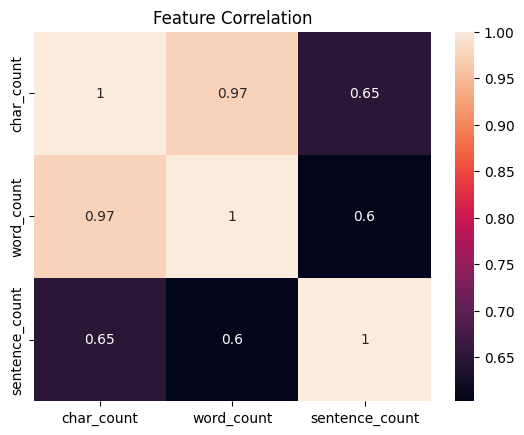

In [20]:
numeric_df = df[['char_count', 'word_count', 'sentence_count']]
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [21]:
df.to_csv("../data/clean_spam.csv", index=False)